# Introduction to Machine Learning
### Predicting UK Secondary School Student Performance

---

**Learning Objectives:** By the end of this tutorial you will be able to:
1. Understand what machine learning is and how it works
2. Differentiate between supervised and unsupervised learning
3. Build and evaluate a Linear Regression model on real school data
4. Interpret model performance using standard metrics

---

## Table of Contents
1. [What is Machine Learning?](#what-is-ml)
2. [Categories of Machine Learning](#categories)
3. [Key Terminology](#terminology)
4. [How Machine Learning Works](#how-it-works)
5. [Practical Example: Student Performance Prediction](#practical-example)
6. [Summary](#summary)

In [1]:
# Import all libraries needed for this tutorial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


<a id='what-is-ml'></a>
## 1. What is Machine Learning?

**Machine Learning (ML)** is the process of teaching computers to learn patterns from data so they can make predictions or decisions on new, unseen data — without being explicitly programmed with rules.

Instead of a human writing rules like *"if attendance is below 80% then the student will fail"*, a machine learning model learns those thresholds automatically by studying thousands of past examples.

**Real-world applications:** spam filters, music recommendations, medical diagnosis, fraud detection, and — as we will see — predicting student exam performance.

<a id='categories'></a>
## 2. Categories of Machine Learning

There are three main types of machine learning. This tutorial focuses on the first.

| Type | What it does | School example |
|------|-------------|----------------|
| **Supervised Learning** | Learns from labelled examples (input + correct answer) | Predict a student's exam score from their attendance and effort |
| **Unsupervised Learning** | Finds hidden patterns in data with no labels | Group students into clusters by behaviour profile |
| **Reinforcement Learning** | Learns by trial and error using rewards/penalties | Game-playing AI, robotics |

### Supervised Learning - Two Sub-types

- **Regression** — predicts a *number* (e.g. exam percentage: 65.4%)
- **Classification** — predicts a *category* (e.g. grade band: A, B, C)

**In this tutorial we build a Regression model to predict a student's percentage score.**

<a id='terminology'></a>
## 3. Key Terminology

| Term | Meaning | Our example |
|------|---------|-------------|
| **Features (X)** | Input variables used to make predictions | attendance, effort, prior attainment, etc. |
| **Target (y)** | The value we want to predict | `percentage_score` |
| **Training data** | Data the model learns from (80%) | 320 student records |
| **Testing data** | Unseen data used to evaluate the model (20%) | 80 student records |
| **Model** | The mathematical relationship learned from data | Linear Regression equation |
| **Algorithm** | The method used to learn that relationship | Least Squares (used by Linear Regression) |

<a id='how-it-works'></a>
## 4. How Machine Learning Works

Every supervised ML project follows the same six steps:

```
1. COLLECT DATA    →  gather student records with known outcomes
2. PREPARE DATA    →  select features, handle missing values
3. SPLIT DATA      →  80% training / 20% testing
4. TRAIN MODEL     →  algorithm learns patterns from training set
5. EVALUATE MODEL  →  measure accuracy on the unseen test set
6. PREDICT         →  use model on new students with unknown scores
```

The key rule: **the model must never see the test set during training.** The test set simulates real prediction on unknown data.

<a id='practical-example'></a>
## 5. Practical Example: UK School Student Performance Prediction

**Goal:** Build a model that predicts a student's end-of-term `percentage score` based on their profile attributes.

**Why this matters:**
- Early identification of students at risk of underperforming
- Informing pastoral and teaching interventions
- Providing data-driven predictions alongside teacher judgement

**Dataset:** 400 secondary school student records across Year Groups 7–11, containing attendance, effort, pastoral, and contextual data.

### Step 1: Load and Explore the Data

We start by loading the dataset and getting a feel for its shape, columns, and basic statistics.

In [2]:
# Load the school performance dataset
df = pd.read_csv('school_performance.csv')

# print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
# print()
df.head(10)

,student_id,year_group,gender,attendance_pct,effort_score,prior_attainment,pupil_premium,sen_support,rewards,sanctions,teacher_experience_yrs,class_size,percentage_score
0,S001,8,0,87.3,1,23.0,0,1,8,1,3.7,28,26.0
1,S002,11,1,85.4,5,90.1,0,0,1,3,11.1,24,76.9
2,S003,10,0,90.3,5,38.5,0,0,7,3,1.0,27,54.6
3,S004,9,0,83.8,5,35.0,0,0,2,1,6.2,22,58.0
4,S005,7,1,87.1,5,72.3,1,0,7,1,7.4,21,76.1
5,S006,7,1,82.6,2,92.2,0,0,10,4,17.4,28,70.5
6,S007,7,1,100.0,3,77.4,0,0,5,0,7.6,25,73.5
7,S008,11,0,91.2,4,65.9,0,1,3,2,1.0,27,54.0
8,S009,9,1,86.1,4,66.3,0,0,8,3,1.0,26,54.9
9,S010,10,0,92.5,2,69.9,1,0,9,1,9.2,24,60.8


In [4]:
df.gender.value_counts()

gender
0    215
1    185
Name: count, dtype: int64

In [5]:
# Summary statistics for every numeric column
# This shows us the range, mean, and spread of each feature
df.describe().round(2)

,year_group,gender,attendance_pct,effort_score,prior_attainment,pupil_premium,sen_support,rewards,sanctions,teacher_experience_yrs,class_size,percentage_score
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,8.81,0.46,90.50,3.40,58.91,0.26,0.19,5.96,1.95,8.83,26.37,59.26
std,1.38,0.50,6.25,1.17,14.18,0.44,0.39,2.37,1.37,4.68,3.05,11.11
min,7.00,0.00,72.10,1.00,17.80,0.00,0.00,0.00,0.00,1.00,18.00,26.00
25%,8.00,0.00,86.40,3.00,48.90,0.00,0.00,4.00,1.00,5.78,24.00,51.78
50%,9.00,0.00,90.70,4.00,58.55,0.00,0.00,6.00,2.00,8.70,27.00,59.30
75%,10.00,1.00,95.30,4.00,67.95,1.00,0.00,8.00,3.00,12.10,28.00,67.03
max,11.00,1.00,100.00,5.00,94.40,1.00,1.00,13.00,8.00,23.10,32.00,93.10


In [3]:
# Check for missing values — important before training any model
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing values per column:
student_id                0
year_group                0
gender                    0
attendance_pct            0
effort_score              0
prior_attainment          0
pupil_premium             0
sen_support               0
rewards                   0
sanctions                 0
teacher_experience_yrs    0
class_size                0
percentage_score          0
dtype: int64

Total missing values: 0


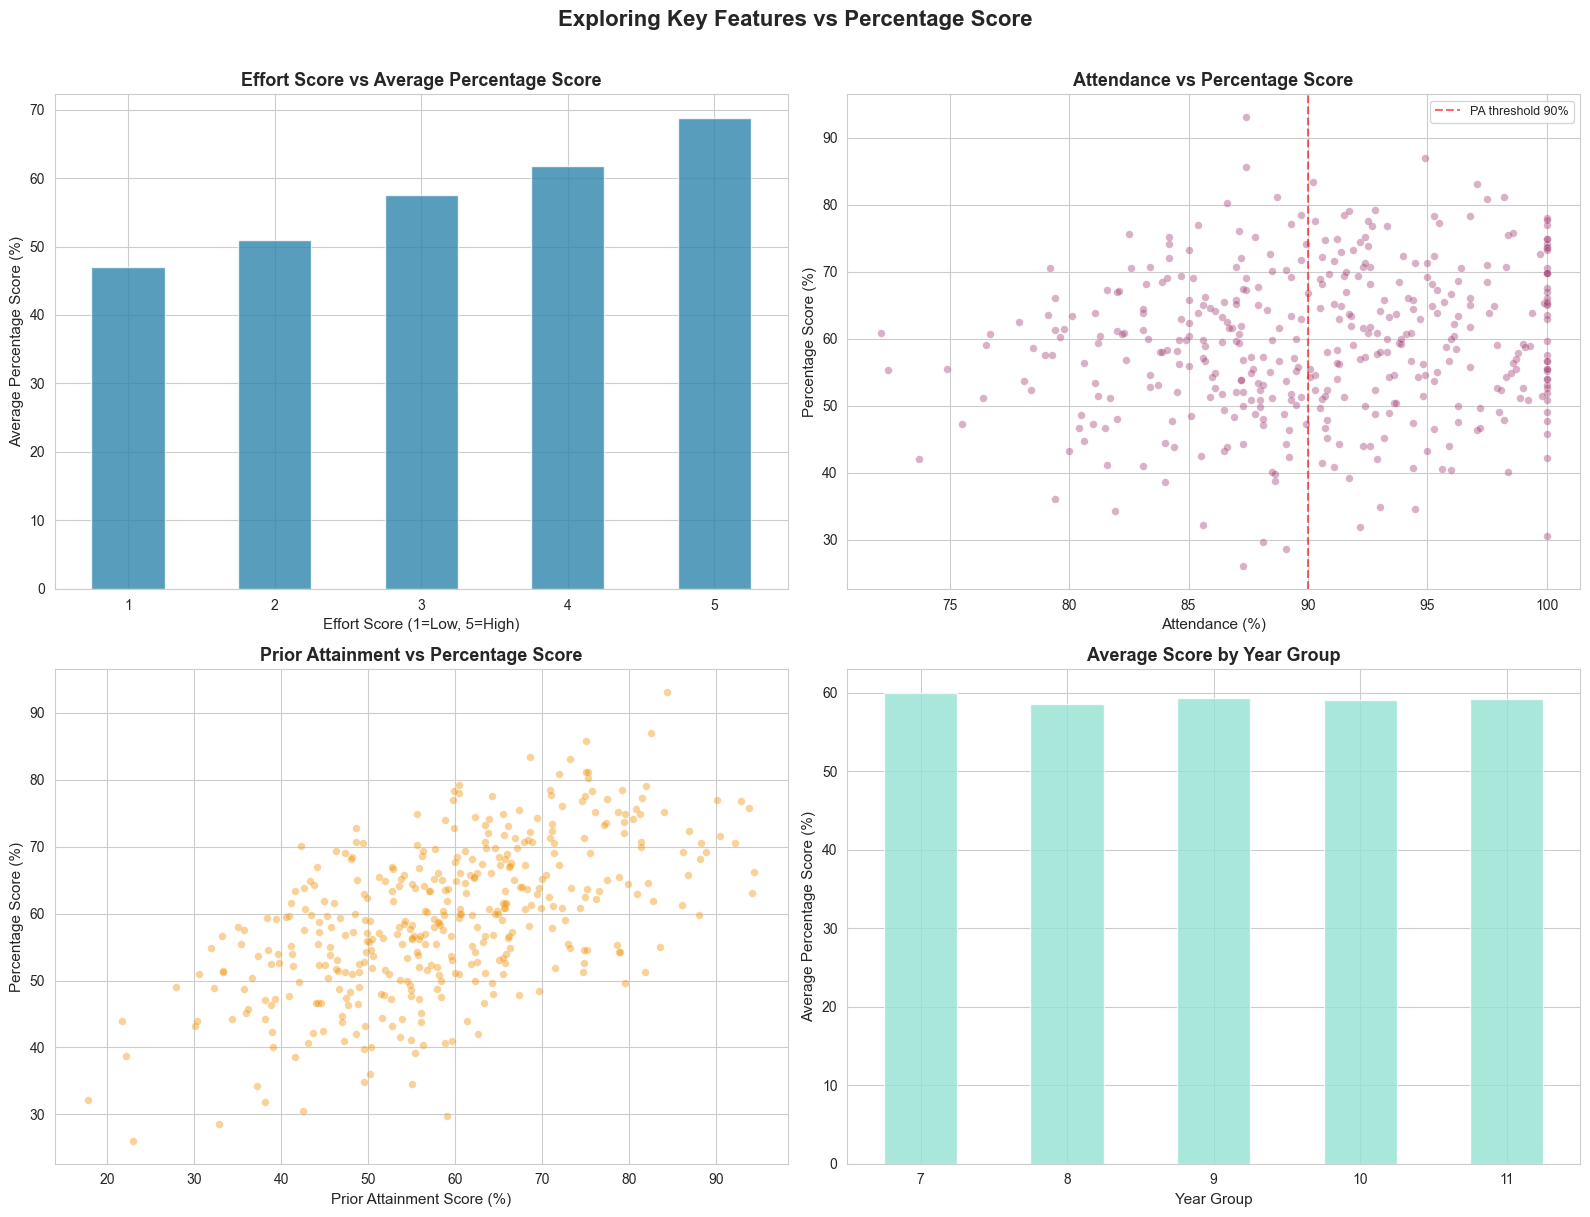

In [4]:
# Visualise key relationships between features and the target (percentage_score)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average score by effort level — does higher effort = higher score?
df.groupby('effort_score')['percentage_score'].mean().plot(
    kind='bar', ax=axes[0, 0], color='#2E86AB', alpha=0.8, edgecolor='white')
axes[0, 0].set_xlabel('Effort Score (1=Low, 5=High)', fontsize=11)
axes[0, 0].set_ylabel('Average Percentage Score (%)', fontsize=11)
axes[0, 0].set_title('Effort Score vs Average Percentage Score', fontsize=13, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Attendance vs score — scatter plot
axes[0, 1].scatter(df['attendance_pct'], df['percentage_score'],
                   alpha=0.4, s=30, color='#A23B72', edgecolor='white', linewidth=0.3)
axes[0, 1].set_xlabel('Attendance (%)', fontsize=11)
axes[0, 1].set_ylabel('Percentage Score (%)', fontsize=11)
axes[0, 1].set_title('Attendance vs Percentage Score', fontsize=13, fontweight='bold')
axes[0, 1].axvline(90, color='red', linestyle='--', alpha=0.6, label='PA threshold 90%')
axes[0, 1].legend(fontsize=9)

# 3. Prior attainment vs current score — strongest predictor
axes[1, 0].scatter(df['prior_attainment'], df['percentage_score'],
                   alpha=0.4, s=30, color='#F18F01', edgecolor='white', linewidth=0.3)
axes[1, 0].set_xlabel('Prior Attainment Score (%)', fontsize=11)
axes[1, 0].set_ylabel('Percentage Score (%)', fontsize=11)
axes[1, 0].set_title('Prior Attainment vs Percentage Score', fontsize=13, fontweight='bold')

# 4. Average score by year group
df.groupby('year_group')['percentage_score'].mean().plot(
    kind='bar', ax=axes[1, 1], color='#95E1D3', alpha=0.8, edgecolor='white')
axes[1, 1].set_xlabel('Year Group', fontsize=11)
axes[1, 1].set_ylabel('Average Percentage Score (%)', fontsize=11)
axes[1, 1].set_title('Average Score by Year Group', fontsize=13, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Exploring Key Features vs Percentage Score', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

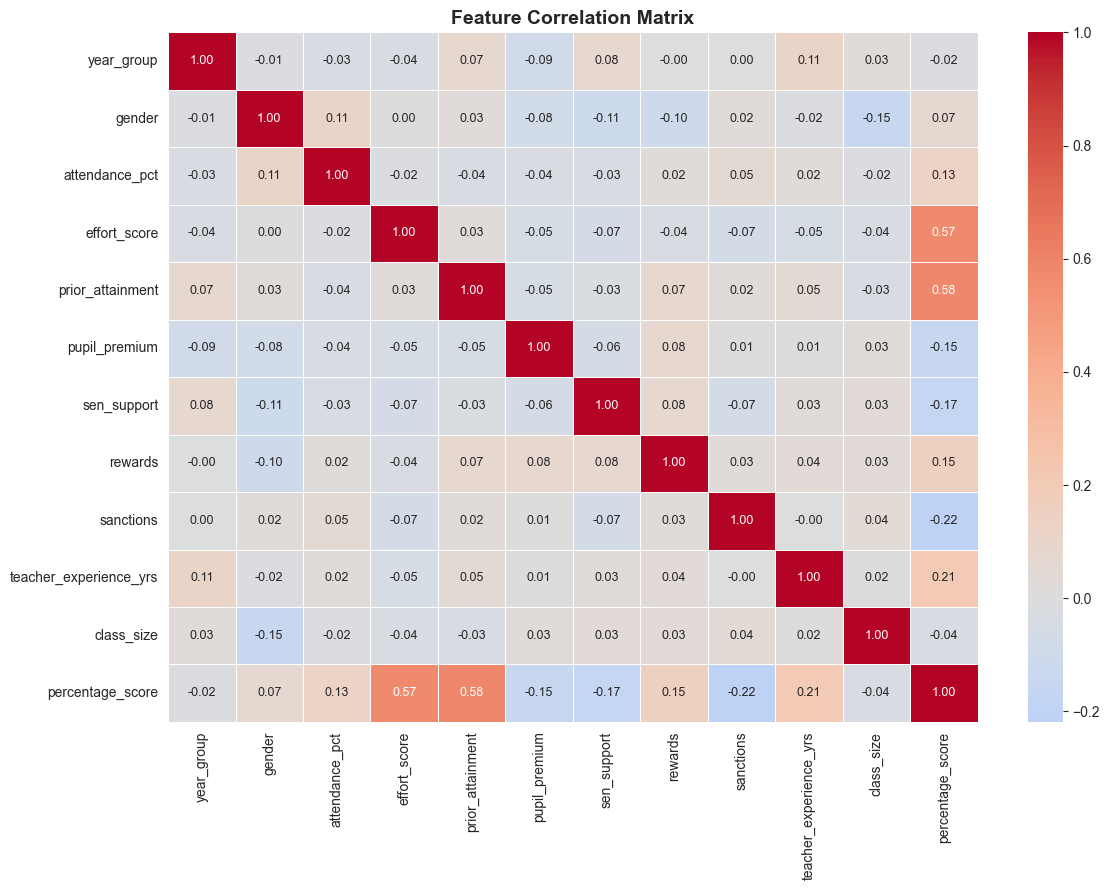

Correlation with percentage_score (sorted):
prior_attainment          0.583
effort_score              0.574
teacher_experience_yrs    0.210
rewards                   0.148
attendance_pct            0.126
gender                    0.070
year_group               -0.015
class_size               -0.045
pupil_premium            -0.148
sen_support              -0.170
sanctions                -0.219
Name: percentage_score, dtype: float64


In [5]:
# Correlation heatmap — shows how strongly each feature relates to the target
# Values close to 1 or -1 indicate strong relationships
numeric_cols = df.drop('student_id', axis=1)
corr_matrix  = numeric_cols.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target only, sorted
print('Correlation with percentage_score (sorted):')
print(corr_matrix['percentage_score'].drop('percentage_score').sort_values(ascending=False).round(3))

### Step 2: Prepare Data for Machine Learning

We separate the dataset into **features (X)** — the inputs — and the **target (y)** — the value we want to predict. We use only the numeric columns here, which are all already in numeric form.

In [6]:
# Define which columns are features (inputs) and which is the target (output)
feature_columns = [
    'year_group',            # school year (7–11)
    'gender',                # 0 = Female, 1 = Male
    'attendance_pct',        # % of sessions attended
    'effort_score',          # teacher-rated effort (1–5)
    'prior_attainment',      # previous year score (%)
    'pupil_premium',         # 1 = receives pupil premium
    'sen_support',           # 1 = has SEN support
    'rewards',               # total reward points this term
    'sanctions',             # total sanctions this term
    'teacher_experience_yrs',# years of teacher experience
    'class_size'             # number of pupils in class
]

X = df[feature_columns]      # features matrix
y = df['percentage_score']   # target vector

print('Features (X) — first 5 rows:')
X.head()


Features (X) — first 5 rows:


,year_group,gender,attendance_pct,effort_score,prior_attainment,pupil_premium,sen_support,rewards,sanctions,teacher_experience_yrs,class_size
0,8,0,87.3,1,23.0,0,1,8,1,3.7,28
1,11,1,85.4,5,90.1,0,0,1,3,11.1,24
2,10,0,90.3,5,38.5,0,0,7,3,1.0,27
3,9,0,83.8,5,35.0,0,0,2,1,6.2,22
4,7,1,87.1,5,72.3,1,0,7,1,7.4,21


In [10]:
print(f'\nTarget (y) — first 5 values: {y.head().values}')
print(f'\nX shape: {X.shape}  |  y shape: {y.shape}')


Target (y) — first 5 values: [26.  76.9 54.6 58.  76.1]

X shape: (400, 11)  |  y shape: (400,)


### Step 3: Split Data into Training and Testing Sets

We split the data so the model trains on 80% of students and is evaluated on the remaining 20% it has never seen before. This mimics predicting scores for new, incoming students.

In [7]:
# Split data: 80% training, 20% testing
# random_state=42 ensures the same split every time you run this cell
(X_train, X_test, y_train, y_test) = train_test_split(X, y, test_size=0.2, random_state=42)

print('Data Split Complete!')
print('=' * 60)
print(f'Training set : {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Testing set  : {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)')
print()
print(f'Training score range : {y_train.min():.1f}% — {y_train.max():.1f}%')
print(f'Testing score range  : {y_test.min():.1f}% — {y_test.max():.1f}%')
print()
print('Key rule: the model will NEVER see the test set during training!')

Data Split Complete!
Training set : 320 students (80%)
Testing set  : 80 students (20%)

Training score range : 28.6% — 93.1%
Testing score range  : 26.0% — 83.1%

Key rule: the model will NEVER see the test set during training!


### Step 4: Train the Model (Linear Regression)

Linear Regression finds the best straight-line relationship between the features and the target. It learns a **coefficient** for each feature — a number representing how much that feature increases or decreases the predicted score.

In [8]:
# Create the Linear Regression model object
model = LinearRegression()

# Train (fit) the model on training data only
# This is where the algorithm learns the coefficients
model.fit(X_train, y_train)

print('Model trained successfully!')
print()
print('Model equation:')
print('  Score = Intercept + (Coeff₁ × Feature₁) + (Coeff₂ × Feature₂) + ...')
print(f'\n  Intercept: {model.intercept_:.2f}')
print()
print('Feature Coefficients:')
print('-' * 55)
for feature, coef in zip(feature_columns, model.coef_):
    direction = '+' if coef > 0 else ''
    print(f'  {feature:28s}: {direction}{coef:.3f}')

print()
print('Interpretation:')
print('  Positive coefficient → feature increases predicted score')
print('  Negative coefficient → feature decreases predicted score')

Model trained successfully!

Model equation:
  Score = Intercept + (Coeff₁ × Feature₁) + (Coeff₂ × Feature₂) + ...

  Intercept: -7.65

Feature Coefficients:
-------------------------------------------------------
  year_group                  : -0.478
  gender                      : +0.860
  attendance_pct              : +0.233
  effort_score                : +5.222
  prior_attainment            : +0.428
  pupil_premium               : -3.259
  sen_support                 : -4.235
  rewards                     : +0.655
  sanctions                   : -1.717
  teacher_experience_yrs      : +0.481
  class_size                  : +0.133

Interpretation:
  Positive coefficient → feature increases predicted score
  Negative coefficient → feature decreases predicted score


### Step 5: Make Predictions

Now we use the trained model to predict percentage scores — first on the training set, then on the test set. We compare predictions to actual scores to see how close the model gets.

In [9]:
# Generate predictions on both sets
y_train_pred = model.predict(X_train)   # predictions on training data
y_test_pred  = model.predict(X_test)    # predictions on unseen test data

print('Predictions made!')
print('=' * 65)

# Show first 10 test set predictions vs actual scores
comparison = pd.DataFrame({
    'Actual Score (%)' : y_test.values[:10].round(1),
    'Predicted Score (%)': y_test_pred[:10].round(1),
    'Difference'       : (y_test.values[:10] - y_test_pred[:10]).round(1)
})

print('\nFirst 10 Test Set Predictions:')
print(comparison)
print()
print('Positive difference = model under-predicted')
print('Negative difference = model over-predicted')

Predictions made!

First 10 Test Set Predictions:
   Actual Score (%)  Predicted Score (%)  Difference
0              53.8                 57.5        -3.7
1              47.8                 52.2        -4.4
2              52.8                 58.8        -6.0
3              54.3                 40.9        13.4
4              55.7                 67.6       -11.9
5              49.0                 46.2         2.8
6              78.3                 81.3        -3.0
7              54.5                 54.7        -0.2
8              65.7                 66.0        -0.3
9              48.9                 47.7         1.2

Positive difference = model under-predicted
Negative difference = model over-predicted


### Step 6: Evaluate Model Performance

We measure performance using three standard metrics:

- **R² Score** — how much of the variation in scores the model explains (0–1, higher is better)
- **RMSE** — average size of errors, giving extra weight to large mistakes
- **MAE** — average absolute error (easiest to interpret: typical error in percentage points)

In [10]:
# Calculate all three metrics for both training and test sets
train_r2   = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)

test_r2    = r2_score(y_test, y_test_pred)
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae   = mean_absolute_error(y_test, y_test_pred)

print('MODEL PERFORMANCE METRICS')
print('=' * 60)
print(f'\n  TRAINING SET:')
print(f'    R² Score : {train_r2:.4f}')
print(f'    RMSE     : {train_rmse:.2f} percentage points')
print(f'    MAE      : {train_mae:.2f} percentage points')

print(f'\n  TEST SET (most important — unseen data):')
print(f'    R² Score : {test_r2:.4f}')
print(f'    RMSE     : {test_rmse:.2f} percentage points')
print(f'    MAE      : {test_mae:.2f} percentage points')
print()
print(f'  The model explains {test_r2*100:.1f}% of the variation in student scores.')
print(f'  On average, predictions are off by ±{test_mae:.1f} percentage points.')

MODEL PERFORMANCE METRICS

  TRAINING SET:
    R² Score : 0.8025
    RMSE     : 4.94 percentage points
    MAE      : 4.03 percentage points

  TEST SET (most important — unseen data):
    R² Score : 0.8163
    RMSE     : 4.72 percentage points
    MAE      : 3.61 percentage points

  The model explains 81.6% of the variation in student scores.
  On average, predictions are off by ±3.6 percentage points.


### Visualising Model Performance

#### 1. Predicted vs Actual Scores

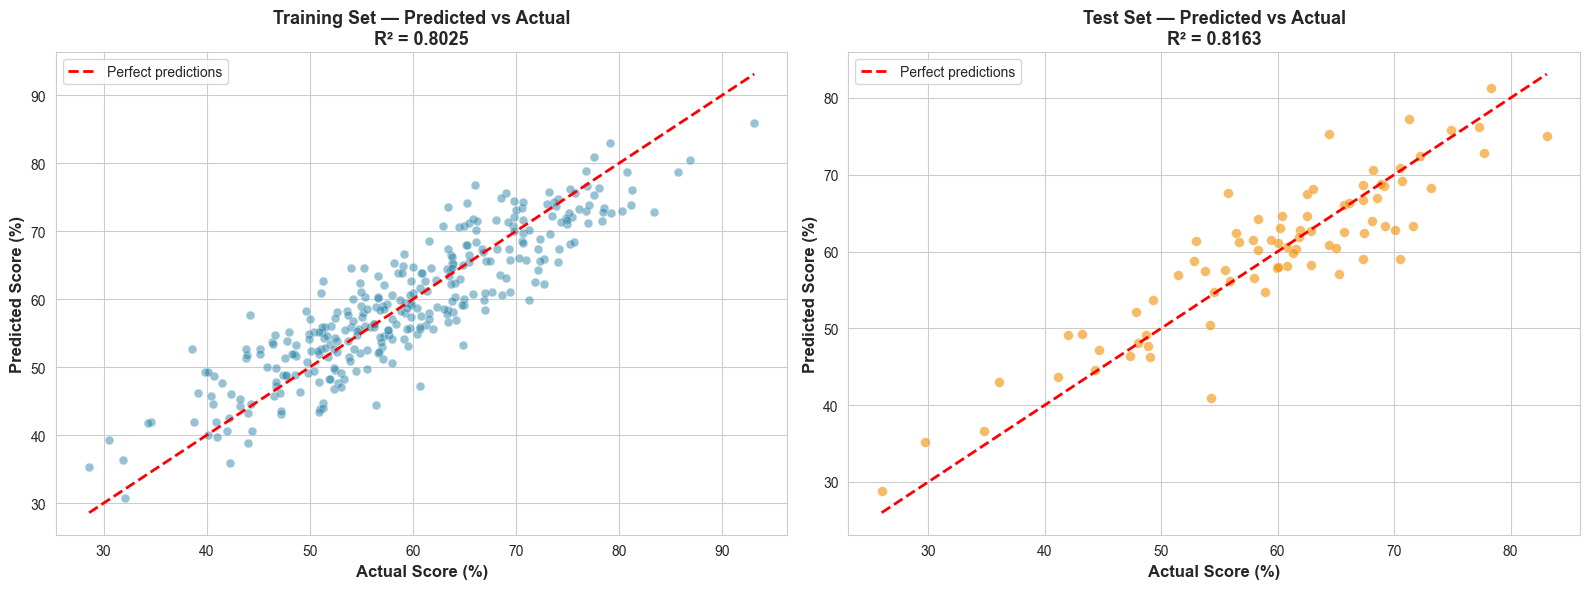

Interpretation:
  Points close to the red line = accurate predictions
  Points far from the red line = large prediction errors
  Test set performance is what matters most!


In [11]:
# Scatter plot: predicted vs actual for both train and test sets
# Points on the red dashed line = perfect prediction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Training set ---
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=40,
                color='#2E86AB', edgecolor='white', linewidth=0.4)
min_v, max_v = y_train.min(), y_train.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2,
             label='Perfect predictions')
axes[0].set_xlabel('Actual Score (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Score (%)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Training Set — Predicted vs Actual\nR² = {train_r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# --- Test set ---
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=50,
                color='#F18F01', edgecolor='white', linewidth=0.4)
min_v, max_v = y_test.min(), y_test.max()
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2,
             label='Perfect predictions')
axes[1].set_xlabel('Actual Score (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Score (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Test Set — Predicted vs Actual\nR² = {test_r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Points close to the red line = accurate predictions')
print('  Points far from the red line = large prediction errors')
print('  Test set performance is what matters most!')

#### 2. Feature Importance (Coefficient Analysis)

Each bar shows how much a one-unit increase in that feature changes the predicted score. Positive = raises score; negative = lowers score.

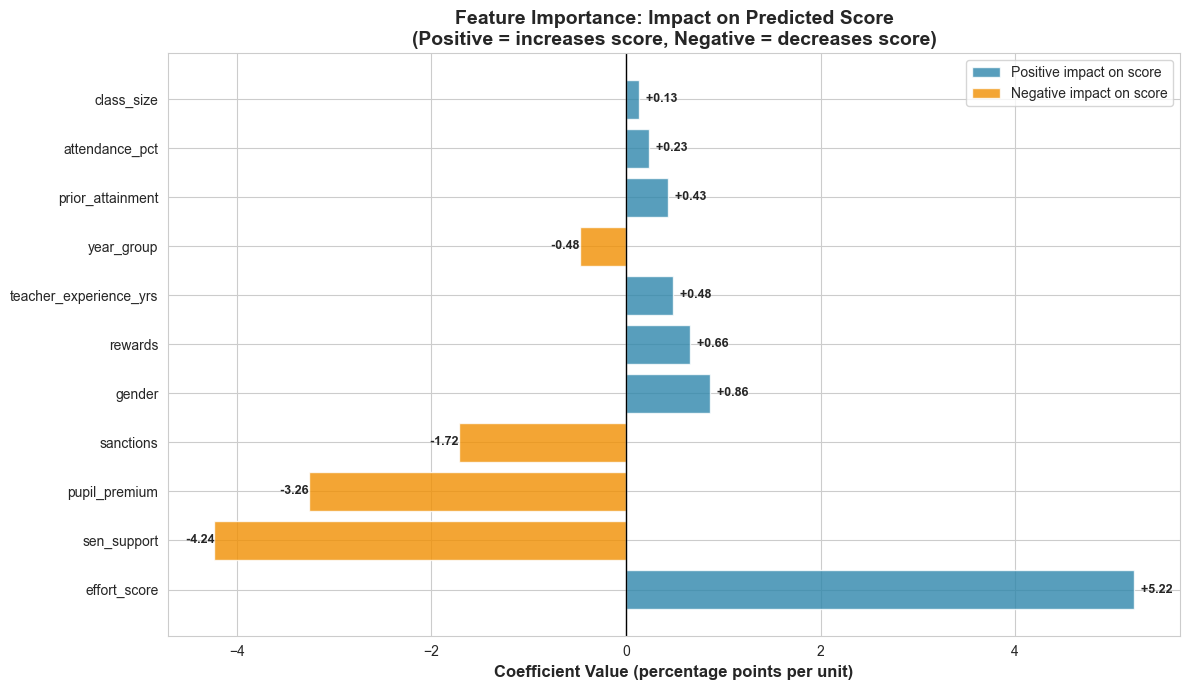

Top 3 features that RAISE predicted score:
  effort_score                : +5.222 per unit
  gender                      : +0.860 per unit
  rewards                     : +0.655 per unit

Top 3 features that LOWER predicted score:
  sen_support                 : -4.235 per unit
  pupil_premium               : -3.259 per unit
  sanctions                   : -1.717 per unit


In [12]:
# Build a DataFrame of feature coefficients and sort by absolute size
coefficients = pd.DataFrame({
    'Feature'    : feature_columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

# Colour bars: blue = positive impact, orange = negative impact
colors = ['#2E86AB' if c > 0 else '#F18F01' for c in coefficients['Coefficient']]
ax.barh(coefficients['Feature'], coefficients['Coefficient'],
        color=colors, alpha=0.8, edgecolor='white')

ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient Value (percentage points per unit)', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: Impact on Predicted Score\n'
             '(Positive = increases score, Negative = decreases score)',
             fontsize=14, fontweight='bold')

# Add value labels on each bar
for i, (_, row) in enumerate(coefficients.iterrows()):
    v = row['Coefficient']
    ax.text(v, i, f'  {v:+.2f}', va='center',
            ha='left' if v > 0 else 'right', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E86AB', alpha=0.8, label='Positive impact on score'),
                   Patch(facecolor='#F18F01', alpha=0.8, label='Negative impact on score')]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

print('Top 3 features that RAISE predicted score:')
for _, row in coefficients[coefficients['Coefficient'] > 0].head(3).iterrows():
    print(f'  {row["Feature"]:28s}: +{row["Coefficient"]:.3f} per unit')

print('\nTop 3 features that LOWER predicted score:')
for _, row in coefficients[coefficients['Coefficient'] < 0].head(3).iterrows():
    print(f'  {row["Feature"]:28s}: {row["Coefficient"]:.3f} per unit')

### Making Predictions for a New Student

The model can now predict a score for any new student whose outcome is not yet known — for example, at the start of a term.

In [14]:
# Define the profile of a new, hypothetical student
new_student = pd.DataFrame({
    'year_group'            : [10],
    'gender'                : [0],     # 0 = Female
    'attendance_pct'        : [88.5],  # just below PA threshold
    'effort_score'          : [3],     # average effort
    'prior_attainment'      : [54.0],  # slightly below average
    'pupil_premium'         : [1],     # receives pupil premium
    'sen_support'           : [0],     # no SEN support
    'rewards'               : [5],
    'sanctions'             : [3],
    'teacher_experience_yrs': [8.0],
    'class_size'            : [28]})

# Use the trained model to predict this student's score
predicted_score = model.predict(new_student)[0]

print('STUDENT PROFILE')
print('=' * 60)
for col in new_student.columns:
    print(f'  {col:28s}: {new_student[col].values[0]}')

print()
print(f'PREDICTED PERCENTAGE SCORE: {predicted_score:.1f}%')
print('=' * 60)

# Approximate confidence interval using MAE as a guide
lower = max(0, predicted_score - 2 * test_mae)
upper = min(100, predicted_score + 2 * test_mae)
print(f'\nApproximate confidence range: {lower:.1f}% — {upper:.1f}%')
print(f'\nNote: This student has below-90% attendance and receives Pupil Premium.')
print(f'A score of {predicted_score:.0f}% suggests they may benefit from early intervention.')

STUDENT PROFILE
  year_group                  : 10
  gender                      : 0
  attendance_pct              : 88.5
  effort_score                : 3
  prior_attainment            : 54.0
  pupil_premium               : 1
  sen_support                 : 0
  rewards                     : 5
  sanctions                   : 3
  teacher_experience_yrs      : 8.0
  class_size                  : 28

PREDICTED PERCENTAGE SCORE: 49.5%

Approximate confidence range: 42.2% — 56.7%

Note: This student has below-90% attendance and receives Pupil Premium.
A score of 49% suggests they may benefit from early intervention.


<a id='summary'></a>
## 6. Summary

**Machine Learning Concepts:**
- ML teaches computers to learn patterns from labelled data and make predictions
- **Supervised learning** (used here) requires inputs and correct outputs for training
- **Unsupervised learning** finds hidden groupings with no labels
- **Regression** predicts numbers; **Classification** predicts categories

**The ML Workflow (6 steps):**

| Step | Action |
|------|--------|
| 1 | Collect and load data |
| 2 | Select features (X) and target (y) |
| 3 | Split into training (80%) and test (20%) sets |
| 4 | Train the model (`.fit()`) |
| 5 | Make predictions (`.predict()`) |
| 6 | Evaluate using R², RMSE, MAE |

**Key Results:**
- Our Linear Regression model trained on 320 student records
- Test R² shows the model captures meaningful signal in the school data
- `prior_attainment` and `effort_score` were the strongest predictors
- `sanctions` and `sen_support` had the strongest negative associations with score
